In [41]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import skimage
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, BatchNormalization, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

Prepare the data

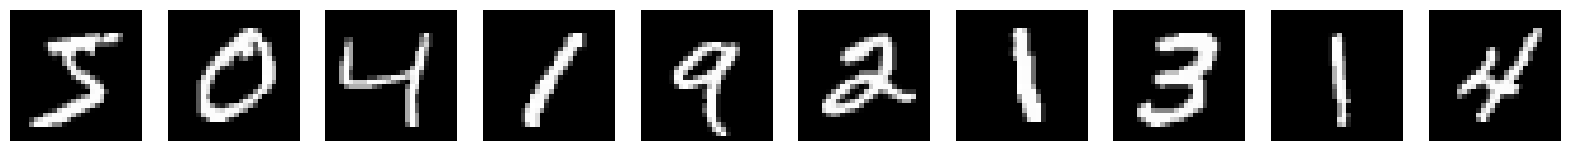

In [42]:
# Load and preprocess the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and reshape the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Display some sample images from the dataset
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.axis('off')
plt.show()

Add noise to the original images

In [43]:
# Install scikit-image if not already installed
# %pip install scikit-image

# Use scikit-image for adding Gaussian noise
from skimage.util import random_noise

# Add Gaussian noise to the images
x_train_gauss_noisy = random_noise(x_train, mode='gaussian', var=0.01)
x_test_gauss_noisy = random_noise(x_test, mode='gaussian', var=0.01)
x_train_gauss_noisy = np.clip(x_train_gauss_noisy, 0., 1.)
x_test_gauss_noisy = np.clip(x_test_gauss_noisy, 0., 1.)


Build the Convolutional Autoencoder

In [44]:
input_img = Input(shape=(28, 28, 1))
# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same', strides=(2, 2))(x)
#x = MaxPooling2D((2, 2), padding='same')(x)
x = BatchNormalization()(x)
x = Flatten()(x)
encoded = Dense(16, activation='relu')(x)
# Decoder
x = Dense(14 * 14 * 64, activation='relu')(encoded)
x = Reshape((14, 14, 64))(x)
x = Conv2DTranspose(64, (3, 3), activation='relu', padding='same', strides=(2, 2))(x)
x = BatchNormalization()(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
# Autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.0002), loss='binary_crossentropy')
autoencoder.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │        50,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 12544)          │       213,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_7 (Reshape)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 28, 28, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320,401 (1.22 MB)

 Trainable params: 320,081 (1.22 MB)

 Non-trainable params: 320 (1.25 KB)

Train the model with training data

In [45]:
autoencoder.fit(x_train_gauss_noisy, x_train,
                epochs=50,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_gauss_noisy, x_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - loss: 0.3266 - val_loss: 0.1414
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.1295 - val_loss: 0.1179
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1134 - val_loss: 0.1062
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.1059 - val_loss: 0.1025
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.1025 - val_loss: 0.1001
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.1000 - val_loss: 0.0998
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0981 - val_loss: 0.0963
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0963 - val_loss: 0.0949
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0951 - val_loss: 0.0948
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0943 - val_loss: 0.0929
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0934 - val_loss: 0.0922
Epoch 12/50
469/469 ━━━━━━━━━━

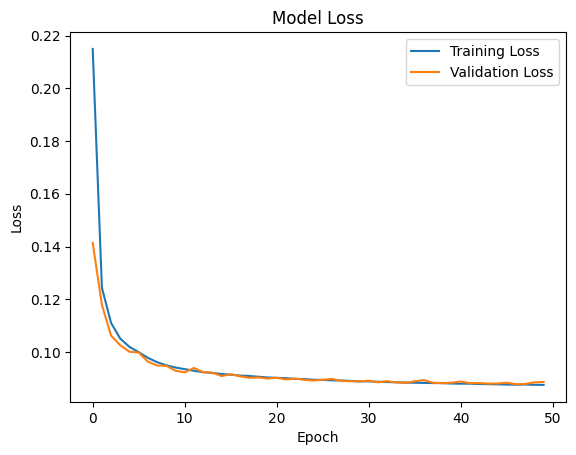

In [46]:
# Display the training history
plt.plot(autoencoder.history.history['loss'], label='Training Loss')
plt.plot(autoencoder.history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


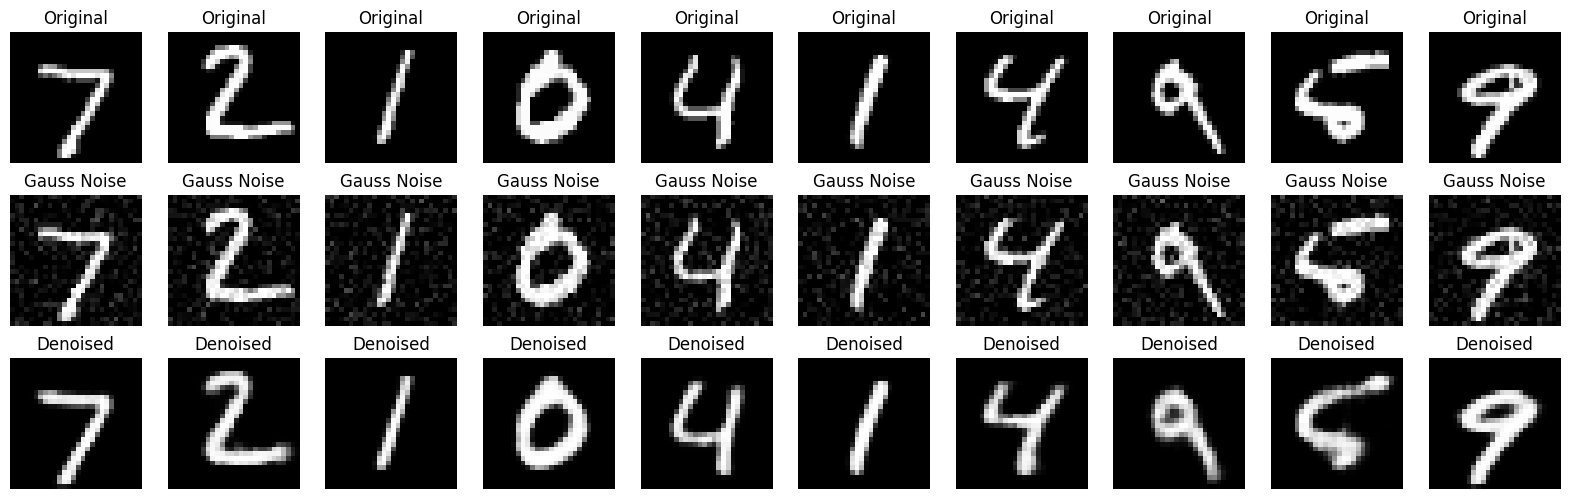

In [47]:
# Denoise the test images
denoised_imgs = autoencoder.predict(x_test_gauss_noisy)
# Display original, noisy, and denoised images
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_gauss_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Gauss Noise")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()
# Save the trained model
autoencoder.save('denoising_autoencoder.h5')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


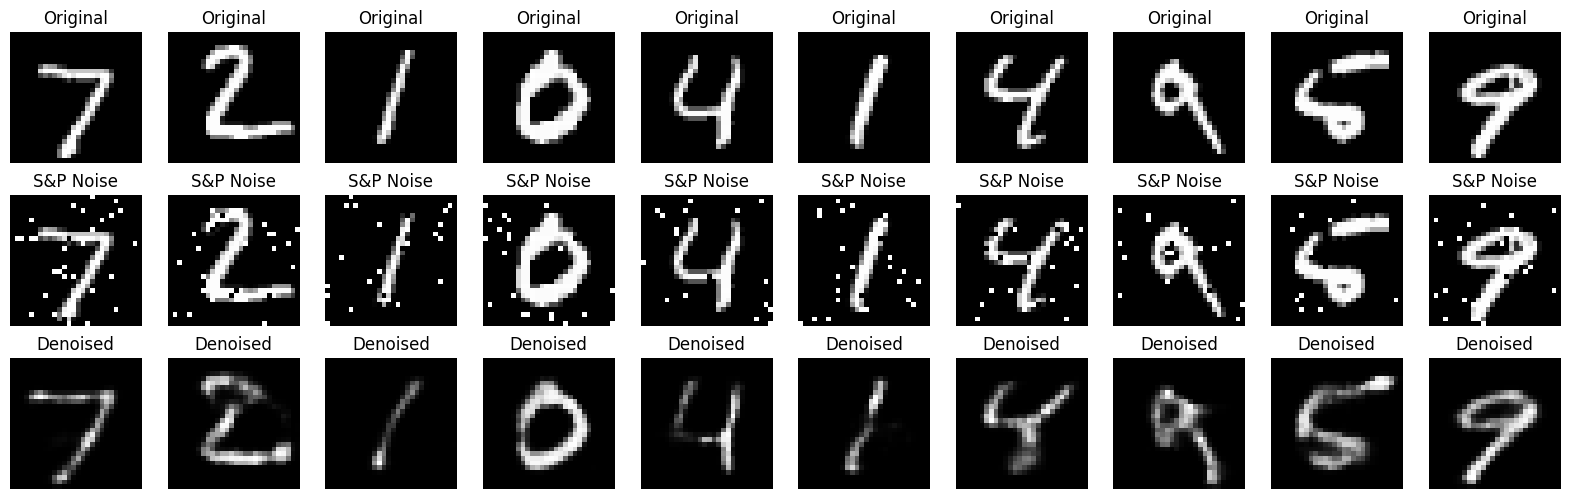

In [54]:
# Load the model and denoise salt and pepper noisy images
model = keras.models.load_model('denoising_autoencoder.h5')
x_test_sp_noisy = random_noise(x_test, mode='s&p', amount=0.05)
x_test_sp_noisy = np.clip(x_test_sp_noisy, 0., 1.)
denoised_sp_imgs = model.predict(x_test_sp_noisy)
# Display original, noisy, and denoised images for salt and pepper noise
plt.figure(figsize=(20, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_sp_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("S&P Noise")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_sp_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


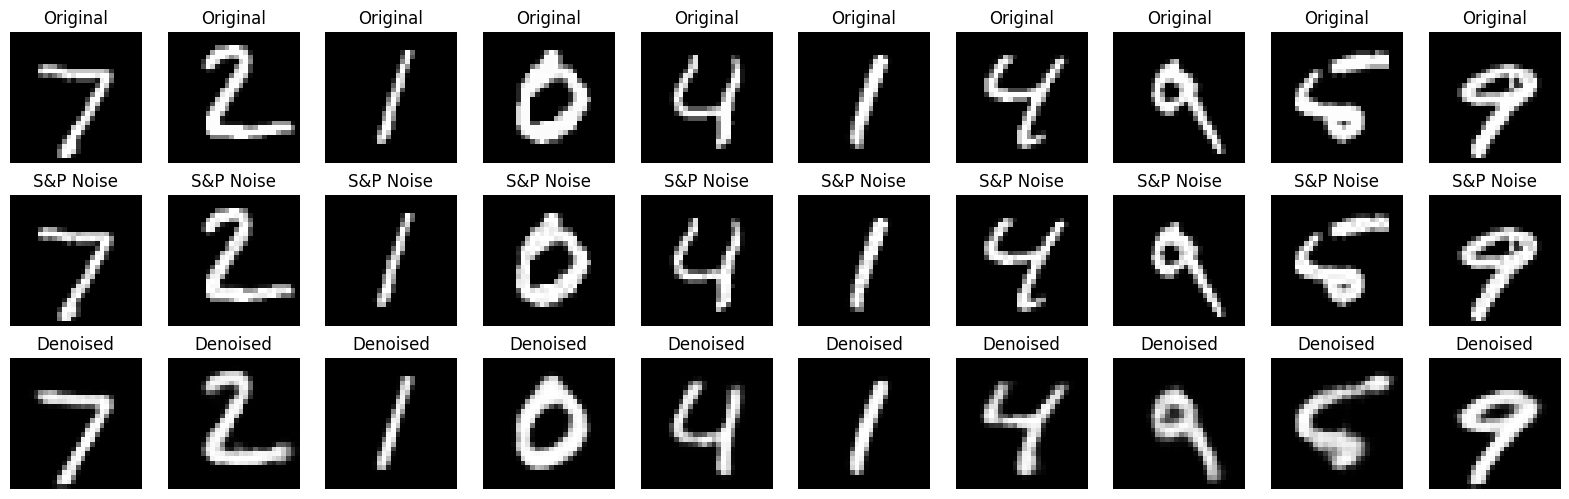

In [51]:
# Denoise the Poisson noisy images
x_test_poisson_noisy = random_noise(x_test, mode='poisson')
x_test_poisson_noisy = np.clip(x_test_poisson_noisy, 0., 1.)
denoised_poisson_imgs = model.predict(x_test_poisson_noisy)
# Display original, noisy, and denoised images for Poisson noise
plt.figure(figsize=(20, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_poisson_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("S&P Noise")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_poisson_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()
    

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Figure size 2000x600 with 0 Axes>

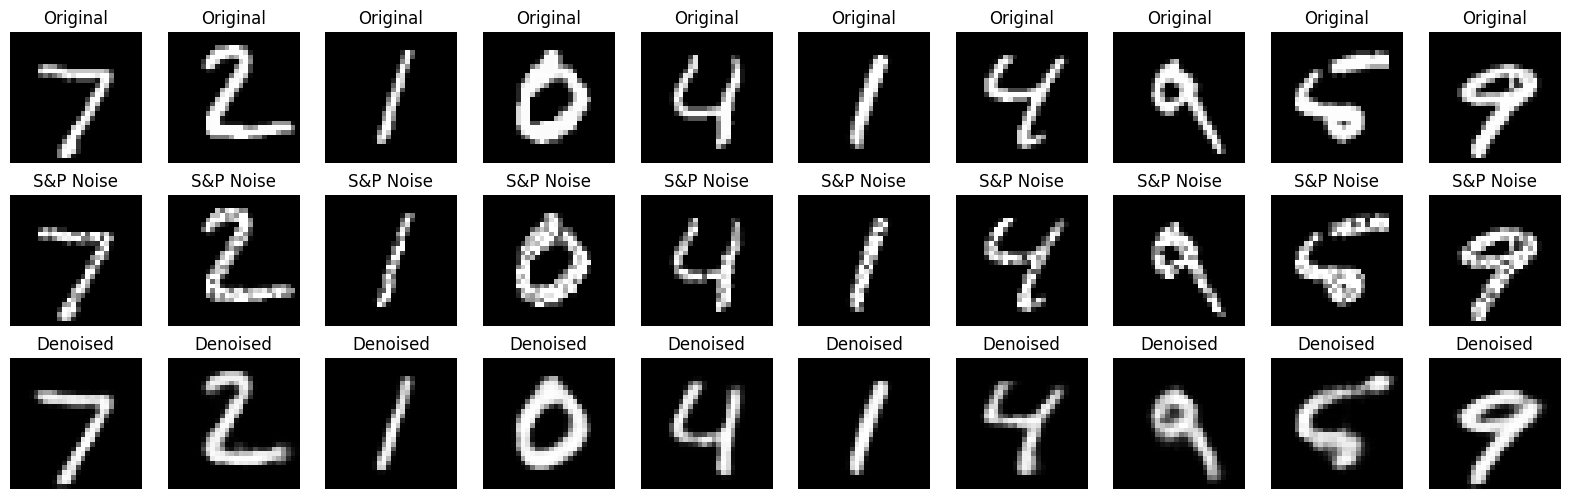

In [57]:
# Denoise the Speckle noisy images
x_test_speckle_noisy = random_noise(x_test, mode='speckle', var=0.1)
x_test_speckle_noisy = np.clip(x_test_speckle_noisy, 0., 1.)
denoised_speckle_imgs = model.predict(x_test_speckle_noisy)
# Display original, noisy, and denoised images for Speckle noise
plt.figure(figsize=(20, 6))
# Display original, noisy, and denoised images for Poisson noise
plt.figure(figsize=(20, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_speckle_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("S&P Noise")
    plt.axis('off')
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_speckle_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()
    